In [1]:
from pyspark.sql import SparkSession

In [2]:
spark=SparkSession.builder.master('local[*]').getOrCreate()

In [3]:
path='/content/drive/MyDrive/Original_data_Olist/'

In [4]:
from pyspark.sql import SparkSession
import os

for file in os.listdir(path):
    if file.endswith(".parquet"):
        df_name = file.replace(".parquet", "")
        globals()[df_name] = spark.read.parquet(os.path.join(path, file))




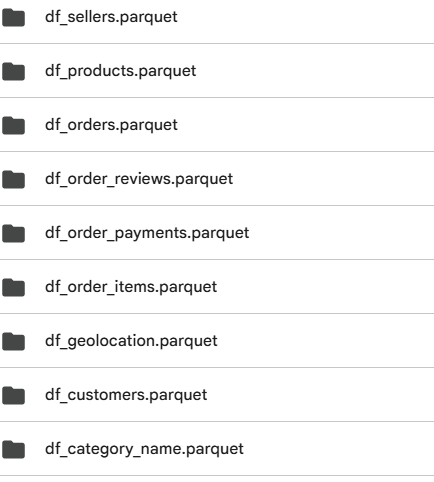

In [5]:
path='/content/drive/MyDrive/cleaned_data_Olist/'

In [6]:
import os

for file in os.listdir(path):
    if file.endswith(".parquet"):
        df_name = file.replace(".parquet", "")
        globals()[df_name] = spark.read.parquet(os.path.join(path, file))

In [7]:
cleaned_data.show(5)

+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+-------------+--------------------+--------------------+-------------------+------+-------------+------------------+-------------+--------------------+-------------+---------------------+--------------------+------------------------+-------------+--------------+
|         customer_id|            order_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|order_item_id|          product_id|           seller_id|shipping_limit_date| price|freight_value|payment_sequential| payment_type|payment_installments|payment_value|payment_value_imputed|  customer_unique_id|customer_zip_code_prefix|customer_city|customer_state|
+--------------------+--------------------+------------+------------------------+-------------

In [8]:
cleaned_payments_df.show(5)

+--------------------+------------------+------------+--------------------+-------------+---------------------+
|            order_id|payment_sequential|payment_type|payment_installments|payment_value|payment_value_imputed|
+--------------------+------------------+------------+--------------------+-------------+---------------------+
|b81ef226f3fe1789b...|                 1| Credit Card|                   8|        99.33|                99.33|
|a9810da82917af2d9...|                 1| Credit Card|                   1|        24.39|                24.39|
|25e8ea4e93396b6fa...|                 1| Credit Card|                   1|        65.71|                65.71|
|ba78997921bbcdc13...|                 1| Credit Card|                   8|       107.78|               107.78|
|42fdf880ba16b47b5...|                 1| Credit Card|                   2|       128.45|               128.45|
+--------------------+------------------+------------+--------------------+-------------+---------------

In [9]:
df_customers_cleaned.show(5)

+--------------------+--------------------+------------------------+-------------+--------------+
|         customer_id|  customer_unique_id|customer_zip_code_prefix|customer_city|customer_state|
+--------------------+--------------------+------------------------+-------------+--------------+
|00012a2ce6f8dcda2...|248ffe10d632bebe4...|                    6273|       osasco|            SP|
|0001fd6190edaaf88...|94b11d37cd61cb299...|                   29830| nova venecia|            ES|
|0002414f953443074...|4893ad4ea28b2c5b3...|                   39664|     mendonca|            MG|
|000379cdec6255224...|0b83f73b19c2019e1...|                    4841|    sao paulo|            SP|
|0004164d20a9e969a...|104bdb7e6a6cdceaa...|                   13272|     valinhos|            SP|
+--------------------+--------------------+------------------------+-------------+--------------+
only showing top 5 rows


In [10]:
df_orders.cache()
df_customers.cache()
df_order_items.cache()

DataFrame[order_id: string, order_item_id: int, product_id: string, seller_id: string, shipping_limit_date: timestamp, price: double, freight_value: double]

In [11]:
order_items_joined_df=df_orders.join(df_order_items,on='order_id',how='inner')

In [12]:
order_items_product_df=order_items_joined_df.join(df_products,on='product_id',how='inner')

In [13]:
from pyspark.sql.functions import *

In [14]:

order_items_product_sellers_df=order_items_product_df.join(broadcast(df_sellers),on='seller_id',how='inner')


In [15]:
full_orders_df=order_items_product_sellers_df.join(df_customers,on='customer_id',how='inner')


In [16]:
df_geolocation.show(5)

+---------------------------+-------------------+------------------+----------------+-----------------+
|geolocation_zip_code_prefix|    geolocation_lat|   geolocation_lng|geolocation_city|geolocation_state|
+---------------------------+-------------------+------------------+----------------+-----------------+
|                       1037| -23.54562128115268|-46.63929204800168|       sao paulo|               SP|
|                       1046|-23.546081127035535|-46.64482029837157|       sao paulo|               SP|
|                       1046| -23.54612896641469|-46.64295148361138|       sao paulo|               SP|
|                       1041|  -23.5443921648681|-46.63949930627844|       sao paulo|               SP|
|                       1035|-23.541577961711493|-46.64160722329613|       sao paulo|               SP|
+---------------------------+-------------------+------------------+----------------+-----------------+
only showing top 5 rows


In [17]:
full_orders_df=full_orders_df.join(broadcast(df_geolocation),on=full_orders_df.customer_zip_code_prefix == df_geolocation.geolocation_zip_code_prefix,how='left')

In [18]:
full_orders_df.show(5)

+--------------------+--------------------+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+-------------+-------------------+-----+-------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+----------------------+-----------+------------+--------------------+------------------------+-------------+--------------+---------------------------+-------------------+------------------+----------------+-----------------+
|         customer_id|           seller_id|          product_id|            order_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|order_item_id|shipping_limit_date|price|freight_value|product_category_name|product_name_lenght|pr

In [19]:
from pyspark.sql.functions import count,when,col

In [21]:
full_orders_df.select([count(when(col(c).isNull(),c)).alias(c) for c in full_orders_df.columns]).show()

+-----------+---------+----------+--------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+-------------+-------------------+-----+-------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+----------------------+-----------+------------+------------------+------------------------+-------------+--------------+---------------------------+---------------+---------------+----------------+-----------------+
|customer_id|seller_id|product_id|order_id|order_status|order_purchase_timestamp|order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|order_item_id|shipping_limit_date|price|freight_value|product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|

In [22]:
full_orders_df=full_orders_df.join(broadcast(df_order_reviews),'order_id','left')

In [23]:
full_orders_df.cache()

DataFrame[order_id: string, customer_id: string, seller_id: string, product_id: string, order_status: string, order_purchase_timestamp: timestamp, order_approved_at: timestamp, order_delivered_carrier_date: timestamp, order_delivered_customer_date: timestamp, order_estimated_delivery_date: timestamp, order_item_id: int, shipping_limit_date: timestamp, price: double, freight_value: double, product_category_name: string, product_name_lenght: int, product_description_lenght: int, product_photos_qty: int, product_weight_g: int, product_length_cm: int, product_height_cm: int, product_width_cm: int, seller_zip_code_prefix: int, seller_city: string, seller_state: string, customer_unique_id: string, customer_zip_code_prefix: int, customer_city: string, customer_state: string, geolocation_zip_code_prefix: int, geolocation_lat: double, geolocation_lng: double, geolocation_city: string, geolocation_state: string, review_id: string, review_score: string, review_comment_title: string, review_commen

In [24]:
# Total revenue per sellers

In [25]:
seller_rev_df=full_orders_df.groupBy('seller_id').agg({'price':'sum'}).alias('total_revenue')

In [26]:
seller_rev_df.show()

+--------------------+--------------------+
|           seller_id|          sum(price)|
+--------------------+--------------------+
|0ea22c1cfbdc755f8...|  1663953.5000000072|
|8e6cc767478edae94...|  1017063.2600000012|
|ff063b022a9a0aab9...|           1828354.0|
|7aa4334be125fcdd2...|  2452878.6799999997|
|602044f2c16190c2c...|    511238.809999999|
|ef0ace09169ac0905...|   2243785.300000002|
|a673821011d0cec28...|   2121539.690000002|
|9c0e69c7bf2619675...|   5722764.219999979|
|900ba814c251a6925...|    4521228.50000002|
|fe2032dab1a61af87...|1.0215717659999987E7|
|b76dba6c951ab00dc...|   294175.1599999988|
|7a67c85e85bb2ce85...|1.9418693210000023E7|
|5343d0649eca2a983...|   1389390.649999996|
|d2374cbcbb3ca4ab1...|   3174987.860000028|
|729f06993dac8e860...|   2711104.960000006|
|9de4643a8dbde634f...|  2327496.2200000007|
|1e8b33f18b4f7598d...|  3033088.9999999963|
|70a12e78e608ac311...|   4667700.779999998|
|238fac594e170b59c...|            480044.0|
|640e21a7d01df7614...|  1048162.

In [27]:
seller_rev_df.cache()

DataFrame[seller_id: string, sum(price): double]

In [28]:
# Total Orders Per Customer

customer_order_count_df = full_orders_df.groupBy('customer_id')\
.agg(count('order_id').alias('total_orders'))\
.orderBy(desc('total_orders'))

customer_order_count_df.show(5)

+--------------------+------------+
|         customer_id|total_orders|
+--------------------+------------+
|5c87184371002d49e...|        6876|
|d5f2b3f597c7ccafb...|        6706|
|c2f18647725395af4...|        6612|
|1ff773612ab8934db...|        5820|
|78fc46047c4a639e8...|        5200|
+--------------------+------------+
only showing top 5 rows


In [29]:
#Average Review Score Per Seller

seller_review_df = full_orders_df.groupBy('seller_id')\
.agg(avg('review_score').alias('avg_review_score'))\
.orderBy(desc('avg_review_score')).show(5)

+--------------------+----------------+
|           seller_id|avg_review_score|
+--------------------+----------------+
|a7ecf689b40a44361...|             5.0|
|2bd05d410a8fd26dc...|             5.0|
|2fa13c8bd5705d279...|             5.0|
|4bde6149c15cf7e17...|             5.0|
|615c3462099ffa940...|             5.0|
+--------------------+----------------+
only showing top 5 rows


In [30]:
# Top 10 Most Sold Products

top_products_df = full_orders_df.groupBy('product_id')\
.agg(count('order_id').alias('total_sold'))\
.orderBy(desc('total_sold')).show(5)

+--------------------+----------+
|          product_id|total_sold|
+--------------------+----------+
|aca2eb7d00ea1a7b8...|     82843|
|422879e10f4668299...|     78769|
|99a4788cb24856965...|     74524|
|389d119b48cf3043d...|     58996|
|d1c427060a0f73f6b...|     57210|
+--------------------+----------+
only showing top 5 rows


In [31]:
full_orders_df.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (null

In [32]:
# Top 10 customers By spending

top_10_spending_df = full_orders_df.groupBy('customer_id')\
.agg(sum('price').alias('Total_amt_spent'))\
.orderBy(desc('Total_amt_spent')).show(10)

+--------------------+------------------+
|         customer_id|   Total_amt_spent|
+--------------------+------------------+
|df55c14d1476a9a34...|         3565657.0|
|ec5b2ba62e5743423...|         2556120.0|
|05455dfa7cd02f13d...| 2160194.400000087|
|349509b216bd5ec11...|         1923627.0|
|695476b5848d64ba0...|1820543.1299999943|
|73236a0796f53d60d...|         1755520.0|
|cc803a2c412833101...|         1676400.0|
|1ff773612ab8934db...|1658641.7999999512|
|fced842c7dad61e8c...|         1654898.0|
|fe5113a38e3575c04...|         1646802.0|
+--------------------+------------------+
only showing top 10 rows


## Windows Function and Ranking

In [33]:
from pyspark.sql.window import Window

In [34]:
window_spec=Window.partitionBy('seller_id').orderBy(desc('price'))

In [35]:
# Rank the top selling products by price
top_seller_prod_df=full_orders_df.withColumn('rank',rank().over(window_spec)).filter('rank<=5')
top_seller_prod_df.select('seller_id','price','rank').show()

+--------------------+-----+----+
|           seller_id|price|rank|
+--------------------+-----+----+
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
|0015a82c2db000af6...|895.0|   1|
+--------------------+-----+----+
only showing top 20 rows


## Advanced Aggregation and Enrichment

In [36]:
# Total Revenue & Average Order Value (AOV) per Customer

customer_spending_df = full_orders_df.groupBy('customer_id')\
.agg(
count('order_id').alias('total_orders'),
sum('price').alias('total_spent'),
round(avg('price'),2).alias('AOV')
)\
.orderBy(desc('total_spent'))

customer_spending_df.show(5)

+--------------------+------------+------------------+-------+
|         customer_id|total_orders|       total_spent|    AOV|
+--------------------+------------+------------------+-------+
|df55c14d1476a9a34...|         743|         3565657.0| 4799.0|
|ec5b2ba62e5743423...|        1428|         2556120.0| 1790.0|
|05455dfa7cd02f13d...|        2184| 2160194.400000087|  989.1|
|349509b216bd5ec11...|         743|         1923627.0| 2589.0|
|695476b5848d64ba0...|         687|1820543.1299999943|2649.99|
+--------------------+------------+------------------+-------+
only showing top 5 rows


In [37]:
# Seller Performance Metrics ( Revenue, Average Review, Order Count)
seller_performance_df = full_orders_df.groupBy('seller_id') \
.agg(
count('order_id').alias('total_orders'),
sum('price').alias('total_revenue'),
round(avg('review_score'),2).alias('avg_review_score'),
round(stddev('price'),2).alias('price_variability')
)\
.orderBy(desc('total_revenue'))

In [38]:
seller_performance_df.show(5)

+--------------------+------------+--------------------+----------------+-----------------+
|           seller_id|total_orders|       total_revenue|avg_review_score|price_variability|
+--------------------+------------+--------------------+----------------+-----------------+
|4869f7a5dfa277a7d...|      180094|3.5026631519999966E7|            4.11|           109.06|
|4a3ca9315b744ce9f...|      302454|3.1306048489999816E7|            3.77|            61.06|
|53243585a1d6dc264...|       49457|3.0586222569999974E7|            4.12|            490.0|
|7c67e1448b00f6e96...|      219479|3.0549908499999758E7|            3.37|            49.85|
|fa1c13f2614d7b5c4...|       84830|2.9024774400000043E7|            4.39|           308.83|
+--------------------+------------+--------------------+----------------+-----------------+
only showing top 5 rows


In [39]:
# Product Popularity Metrics
product_metrics_df = full_orders_df.groupBy('product_id')\
.agg(
count('order_id').alias('total_sales'),
sum('price').alias('total_revenue'),
round(avg('price'),2).alias('avg_price'),
round(stddev('price'),2).alias('price_volatility'),\
collect_set('seller_id').alias('unique_sellers')
)\
.orderBy(desc('total_sales'))

In [40]:
product_metrics_df.show(10)

+--------------------+-----------+------------------+---------+----------------+--------------------+
|          product_id|total_sales|     total_revenue|avg_price|price_volatility|      unique_sellers|
+--------------------+-----------+------------------+---------+----------------+--------------------+
|aca2eb7d00ea1a7b8...|      82843| 5891016.200000003|    71.11|            3.23|[955fee9216a65b61...|
|422879e10f4668299...|      78769| 4320042.410000017|    54.84|            4.45|[1f50f920176fa81d...|
|99a4788cb24856965...|      74524| 6545173.110000008|    87.83|            4.16|[4a3ca9315b744ce9...|
|389d119b48cf3043d...|      58996|3215134.3300000057|     54.5|            4.39|[1f50f920176fa81d...|
|d1c427060a0f73f6b...|      57210| 7934417.390000002|   138.69|           16.81|[a1043bafd471dff5...|
|368c6c730842d7801...|      56960| 3107335.300000001|    54.55|             4.6|[1f50f920176fa81d...|
|53b36df67ebb7c415...|      51556| 6093549.009999993|   118.19|           20.22|[4

In [41]:
# Monthly Revenue And Order Count Trend

# order_purchase_timestamp --> month

# total_orders
# total_revenue
# avg_order_value
# min_order_value
# max_order_value

In [42]:
full_orders_df.rdd.getNumPartitions()


200

In [43]:
# Customer Retention Analysis (First and Last Order)
# Customer Retention Analysis ( First & Last Order )

customer_retention_df = full_orders_df.groupBy('customer_id')\
.agg(
min('order_purchase_timestamp').alias('first_order_date'),
max('order_purchase_timestamp').alias('last_order_date'),
count('order_id').alias('total_orders'),
round(avg('price'),2).alias('aov')
)\
.orderBy(desc('total_orders'))

In [44]:
customer_retention_df.show(7)

+--------------------+-------------------+-------------------+------------+------+
|         customer_id|   first_order_date|    last_order_date|total_orders|   aov|
+--------------------+-------------------+-------------------+------------+------+
|5c87184371002d49e...|2018-01-05 19:15:37|2018-01-05 19:15:37|        6876| 12.49|
|d5f2b3f597c7ccafb...|2017-12-13 14:21:15|2017-12-13 14:21:15|        6706|  59.0|
|c2f18647725395af4...|2018-03-06 19:21:47|2018-03-06 19:21:47|        6612|  34.9|
|1ff773612ab8934db...|2018-04-19 13:54:06|2018-04-19 13:54:06|        5820|284.99|
|78fc46047c4a639e8...|2017-11-28 22:24:18|2017-11-28 22:24:18|        5200|109.97|
|dd3f1762eb601f41c...|2018-07-18 12:59:21|2018-07-18 12:59:21|        4992|179.99|
|9eb3d566e87289dcb...|2018-06-08 16:42:11|2018-06-08 16:42:11|        4872|  5.11|
+--------------------+-------------------+-------------------+------------+------+
only showing top 7 rows


In [45]:
full_orders_df.createOrReplaceTempView("full_orders")


In [46]:
spark.sql('select * from full_orders').show()

+--------------------+--------------------+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+-------------+-------------------+-----+-------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+----------------------+---------------+------------+--------------------+------------------------+-------------+--------------+---------------------------+-------------------+-------------------+----------------+-----------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+
|            order_id|         customer_id|           seller_id|          product_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|

In [47]:
spark.sql("""
SELECT
    customer_id,
    MIN(order_purchase_timestamp) AS first_order_date,
    MAX(order_purchase_timestamp) AS last_order_date,
    COUNT(order_id)               AS total_orders,
    ROUND(AVG(price), 2)          AS aov
FROM full_orders
GROUP BY customer_id
ORDER BY total_orders DESC
""").show(truncate=False)


+--------------------------------+-------------------+-------------------+------------+------+
|customer_id                     |first_order_date   |last_order_date    |total_orders|aov   |
+--------------------------------+-------------------+-------------------+------------+------+
|5c87184371002d49e08b9ac10eb96647|2018-01-05 19:15:37|2018-01-05 19:15:37|6876        |12.49 |
|d5f2b3f597c7ccafbb5cac0bcc3d6024|2017-12-13 14:21:15|2017-12-13 14:21:15|6706        |59.0  |
|c2f18647725395af4ad8cb9d34ff1287|2018-03-06 19:21:47|2018-03-06 19:21:47|6612        |34.9  |
|1ff773612ab8934db89fd5afa8afe506|2018-04-19 13:54:06|2018-04-19 13:54:06|5820        |284.99|
|78fc46047c4a639e81ff65f0396e02fe|2017-11-28 22:24:18|2017-11-28 22:24:18|5200        |109.97|
|dd3f1762eb601f41c5e289fa08dbc6bf|2018-07-18 12:59:21|2018-07-18 12:59:21|4992        |179.99|
|9eb3d566e87289dcb0acf28e1407c839|2018-06-08 16:42:11|2018-06-08 16:42:11|4872        |5.11  |
|1b2ab6eda1946a6ff386b1ae51431344|2017-11-24 10:41

## Extended Enrichment

In [48]:
# Order Status Flags

full_orders_df = full_orders_df.withColumn('is_delivered', when(col('order_status') == 'delivered', lit(1)).otherwise(lit(0)))\
.withColumn('is_canceled', when(col('order_status') == 'canceled', lit(1)).otherwise(lit(0)))



In [49]:
full_orders_df.select('order_status', 'is_delivered', 'is_canceled').show(100)

+------------+------------+-----------+
|order_status|is_delivered|is_canceled|
+------------+------------+-----------+
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|
|   delivered|           1|          0|


In [50]:
# Order Revenue Calcualtion

full_orders_df = full_orders_df.withColumn('order_revenue',col('price')+col('freight_value'))

full_orders_df.select('price','freight_value','order_revenue').show()

+-----+-------------+------------------+
|price|freight_value|     order_revenue|
+-----+-------------+------------------+
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
| 27.9|         3.81|31.709999999999997|
+-----+-------------+------------------+
only showing top

In [51]:
# Customer Segmentation based on spending

customer_spending_df = customer_spending_df.withColumn(
'customer_segment',
when(col('AOV') >=1200,"High-Value")
.when( (col('AOV')<1200) & (col('AOV') >=5e0), 'Medium_Value')
.otherwise('Low-Value'))

In [52]:
customer_spending_df.show(10)

+--------------------+------------+------------------+-------+----------------+
|         customer_id|total_orders|       total_spent|    AOV|customer_segment|
+--------------------+------------+------------------+-------+----------------+
|df55c14d1476a9a34...|         743|         3565657.0| 4799.0|      High-Value|
|ec5b2ba62e5743423...|        1428|         2556120.0| 1790.0|      High-Value|
|05455dfa7cd02f13d...|        2184| 2160194.400000087|  989.1|    Medium_Value|
|349509b216bd5ec11...|         743|         1923627.0| 2589.0|      High-Value|
|695476b5848d64ba0...|         687|1820543.1299999943|2649.99|      High-Value|
|73236a0796f53d60d...|         832|         1755520.0| 2110.0|      High-Value|
|cc803a2c412833101...|         762|         1676400.0| 2200.0|      High-Value|
|1ff773612ab8934db...|        5820|1658641.7999999512| 284.99|    Medium_Value|
|fced842c7dad61e8c...|         602|         1654898.0| 2749.0|      High-Value|
|fe5113a38e3575c04...|        1146|     

In [53]:
full_orders_df = full_orders_df.join(customer_spending_df.select('customer_id','customer_segment'),'customer_id',how='left')

full_orders_df.select('customer_id','customer_segment').show()

+--------------------+----------------+
|         customer_id|customer_segment|
+--------------------+----------------+
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
|2de342d6e5905a5a8...|    Medium_Value|
+--------------------+----------------+
only showing top 20 rows


In [55]:
full_orders_df.groupBy('customer_segment').count().show()

+----------------+--------+
|customer_segment|   count|
+----------------+--------+
|      High-Value|   94603|
|       Low-Value|   14021|
|    Medium_Value|17190067|
+----------------+--------+



In [56]:
full_orders_df=full_orders_df.withColumn('hour of day',expr('hour(order_purchase_timestamp)'))

In [58]:
full_orders_df.select('order_purchase_timestamp','hour of day').show(10)

+------------------------+-----------+
|order_purchase_timestamp|hour of day|
+------------------------+-----------+
|     2017-07-26 17:38:47|         17|
|     2017-07-26 17:38:47|         17|
|     2017-07-26 17:38:47|         17|
|     2017-07-26 17:38:47|         17|
|     2017-07-26 17:38:47|         17|
|     2017-07-26 17:38:47|         17|
|     2017-07-26 17:38:47|         17|
|     2017-07-26 17:38:47|         17|
|     2017-07-26 17:38:47|         17|
|     2017-07-26 17:38:47|         17|
+------------------------+-----------+
only showing top 10 rows


In [60]:
# Weekday or Weekend
full_orders_df=full_orders_df.withColumn('weekend Order',when(expr('dayofweek(order_purchase_timestamp) in (1,7)'),lit('weekend')).otherwise(lit('weekday')))


In [72]:
full_orders_df.select('order_purchase_timestamp','weekend order').filter(col('weekend order')=='weekend').distinct().show(10)

+------------------------+-------------+
|order_purchase_timestamp|weekend order|
+------------------------+-------------+
|     2017-10-22 11:20:45|      weekend|
|     2017-10-07 15:27:15|      weekend|
|     2018-01-07 11:11:03|      weekend|
|     2017-11-25 17:00:57|      weekend|
|     2017-11-25 09:50:00|      weekend|
|     2018-02-10 20:46:25|      weekend|
|     2017-09-09 18:04:27|      weekend|
|     2017-08-06 13:09:40|      weekend|
|     2018-08-19 17:01:20|      weekend|
|     2018-02-10 12:52:51|      weekend|
+------------------------+-------------+
only showing top 10 rows


In [73]:
full_orders_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (null

In [80]:
full_orders_df.write.mode('overwrite').parquet('/content/drive/MyDrive/cleaned_data_Olist/full_orders_final_df.parquet')

In [78]:
full_orders_df.rdd.getNumPartitions()


10